In [1]:
# Current issues: 
# reliability calculated using potential test images -> data leakage
# make sure feature extraction from clip is deterministic (torch no grad, torch eval)

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import pearsonr, zscore
import seaborn as sns

from tqdm import tqdm
import os
import pickle

# from PSN.psn import psn

import glob
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import r2_score

import imageio.v2 as imageio
import torch
import torch.nn.functional as F
from torchvision import transforms

from transformers import CLIPVisionModelWithProjection, CLIPImageProcessor

from utils import align_channels_across_runs, compute_ncsnr_all_timepoints, reshape_electrode_data_by_stimuli, extract_images_with_n_repeats, ncsnr_figs

# Set random seed for reproducibility
np.random.seed(42)

# helper functions for computing reliability over time

# load data from a subject

In [4]:
base_dir = '/home/ri99/ieeg'
ieeg_dir = f'{base_dir}/data/subjects/111'
csv_dir = f'{base_dir}/data/nsd_PTB'
img_dir = f'{base_dir}/data/nsd_ecog'

data_dir = f'{base_dir}/data/hfb'
output_dir = f'{base_dir}/outputs/hfb'
cache_dir = f'{base_dir}/.cache'

os.makedirs(cache_dir, exist_ok=True)
sub = 11
n_blocks = -1  # -1 = use all blocks
n_runs = 56

sampling_rate = 1024  # Hz
baseline_time = 0.2  # seconds of data per trial before stimulus onset
# subject 111 had 5600 images split into 4 distinct sessions over 2 days (day 1: runs 1-12 and 13-24; day 2: runs 25-36 and 37-56)

load_from_file = True

In [5]:
curric = pd.read_csv(f"{csv_dir}/curriculum_patient{sub}.csv")
curric.head()

,Unnamed: 0,filename,inventory,coco_id,is_repeat,repetition_number,block
0,0,special_23715.png,1x-shared1000_A,23715.0,0,1,1
1,1,notspecial_24264.png,1x-shared1000_A,24264.0,0,1,1
2,2,pair_45_w_pagoda1.png,MST,NaN,0,1,1
3,3,pair_33_nsd_777_1_cocoid_68844.png,MST,68844.0,0,1,1
4,4,notspecial_36682.png,3x-shared1000_A,36682.0,0,1,1


In [6]:
if n_blocks == -1:  # use all available blocks
    block_list = curric['block'].unique().astype(str)
else:  # use n_blocks to specify instead
    block_list = [str(x) for x in range(1, n_blocks+1)]

print(block_list)
image_names = list(curric[curric['block'].isin(block_list)]['filename'])
print(len(image_names))

['1' '2' '3' '4' 'filler_block_1' 'filler_block_2']
5600


In [7]:
# load bipolar-referenced voltage trace data (no frequency decomposition) at 1024Hz
run_list = list(range(1, n_runs+1))

all_data = []
all_labels = []
time_ref = None

for run in tqdm(run_list):
    if load_from_file is False:
        data = np.load(f"{ieeg_dir}/bandpower1024/npy/sub1{sub}_NSD_run{run}_bandpower70-170.npy")
    labels = pd.read_csv(f"{ieeg_dir}/bandpower1024/ch_labels/sub1{sub}_NSD_run{run}_bandpower_channels.csv")
    time = np.load(f"{ieeg_dir}/bandpower1024/time/sub1{sub}_NSD_run{run}_bandpower_time.npy")

    if load_from_file is False:
        assert time.shape[0] == data.shape[2], f"time mismatch in run {run}"
        assert labels.shape[0] == data.shape[1], f"label mismatch in run {run}"
    
    if time_ref is None:
        time_ref = time
    else:
        assert np.allclose(time, time_ref), f"time array differs in run {run}"

    if load_from_file is False:
        all_data.append(data)
    all_labels.append(labels)

if load_from_file is False:
    print(len(all_data))
    del data

# delete to prevent using the wrong ones later; we use channel_info to index channel labels from here on
del labels

100%|██████████| 56/56 [00:00<00:00, 75.28it/s]


In [8]:
if load_from_file is False:
    # combine data across runs while dealing with some runs not having data from the same channels
    data, channel_info = align_channels_across_runs(all_data, all_labels)
    data = data.transpose(1,2,0).astype(np.float16)  # convert to channels x time x trials
    print(f"Final shape: {data.shape}")
    print(channel_info.head())
    channel_info.to_csv(f'{data_dir}/channel_info.csv', index=False)
else:
    channel_info = pd.read_csv(f'{data_dir}/channel_info.csv')

del all_labels

# reshape to identify repeated stimuli

In [9]:
if load_from_file is False:
    # First, reshape your electrode data using the existing function
    reshaped_electrode_data, stim_info = reshape_electrode_data_by_stimuli(
        data,  # Your electrode data (channels, time, trials)
        curric,         # Your events dataframe
        stim_column='coco_id'
    )
    np.save(f'{data_dir}/reshaped_electrode_data', reshaped_electrode_data)
    with open(f'{data_dir}/stim_info.pkl', 'wb') as f:
        pickle.dump(stim_info, f)

else:
    print('loaded reshaped_electrode_data, stim_info from file')
    reshaped_electrode_data = np.load(f'{data_dir}/reshaped_electrode_data.npy')
    with open(f'{data_dir}/stim_info.pkl', 'rb') as f:
        stim_info = pickle.load(f)
    print(reshaped_electrode_data.shape)

loaded reshaped_electrode_data, stim_info from file


In [17]:
print(reshaped_electrode_data.shape)

(130, 2900, 2049, 4)


In [27]:
ranked_channels = pd.read_csv(f'{output_dir}/ncsnr_rankings_desc')
display(ranked_channels.head())

,Unnamed: 0,channel_name,channel_idx
0,3,LAP-pC_2-1,0
1,47,LmO-TP_7-6,40
2,48,LmO-TP_8-7,41
3,104,RmO-TP_15-14,107
4,69,LsT-Pu_7-6,69


In [87]:
# prepare data for prediction
print(reshaped_electrode_data.shape)
k = 4
print(f'averaging over repeats and selecting top {k} reliable channels')
top_k_channels = ranked_channels.iloc[:k]['channel_idx'].values
data_avg = np.nanmean(reshaped_electrode_data[top_k_channels], axis=3)
print(data_avg.shape)

print('downsampling timepoints by averaging in bins')
n_time = data_avg.shape[2]
n_time_bins = 200

bin_edges = np.linspace(0, n_time, n_time_bins + 1, dtype=int)
binned_data = np.empty((data_avg.shape[0], data_avg.shape[1], n_time_bins))
for i in range(n_time_bins):
    start, end = bin_edges[i], bin_edges[i + 1]
    binned_data[:, :, i] = data_avg[:, :, start:end].mean(axis=2)

# binned_data = data_avg

print(binned_data.shape)

(130, 2900, 2049, 4)
averaging over repeats and selecting top 4 reliable channels
(4, 2900, 2049)
downsampling timepoints by averaging in bins
(4, 2900, 200)


In [88]:
np.isnan(binned_data).any(axis=1).any(axis=1)

array([False, False, False, False])

In [10]:
# prepare target CLIP embeddings
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = "laion/CLIP-ViT-H-14-laion2B-s32B-b79K"
image_encoder = CLIPVisionModelWithProjection.from_pretrained(model_name, cache_dir=cache_dir).to(device)
# feature_extractor = CLIPImageProcessor(size=224, crop_size=224)
feature_extractor = CLIPImageProcessor.from_pretrained(model_name, cache_dir=cache_dir)

Using device: cuda


In [11]:
unique_image_indices = [idx[0] for idx in list(stim_info['stimulus_to_trials'].values())]
assert len(unique_image_indices) == stim_info['n_unique_images']
unique_image_names = pd.unique(curric['filename'])

imsize = (224,224)
resize_transform = transforms.Resize(imsize)
data_type = torch.float32

images = torch.empty((len(unique_image_names), 3, imsize[0], imsize[1]), dtype=data_type)
print(images.shape)

torch.Size([2900, 3, 224, 224])


In [12]:
# load images
for i, im_name in tqdm(enumerate(unique_image_names), total=len(unique_image_names)):
    default_path = f"{img_dir}/stimulusfiles/{im_name}"
    if not os.path.exists(default_path):  # non-default case; image isn't in stimulusfiles
        candidates = glob.glob(f"{img_dir}/**/{im_name}", recursive=True)
    
        if len(candidates) == 0:
            raise FileNotFoundError(f"No matching files found for {im_name} under {img_dir}")
    
        imgs = [imageio.imread(path) for path in candidates]
    
        # check for identical matches
        if len(imgs) > 1:
            for j in range(1, len(imgs)):
                if not np.array_equal(imgs[0], imgs[j]):
                    raise ValueError(f"Non-identical duplicates found for {im_name}:\n{candidates}")
    
        im = imgs[0]
    else:  # default case; image in stimulusfiles
        im = imageio.imread(default_path)

    if im.ndim == 2:
        im = np.stack([im]*3, axis=-1)
    elif im.shape[2] == 4:
        im = im[:, :, :3]
    im = torch.tensor(im, dtype=data_type).permute(2,0,1)
    im = resize_transform(im)
    images[i] = im

print(images.shape, type(images), images.dtype)
print(images.min(), images.max())

100%|██████████| 2900/2900 [01:03<00:00, 45.84it/s]


torch.Size([2900, 3, 224, 224]) <class 'torch.Tensor'> torch.float32
tensor(0.) tensor(255.0001)


In [13]:
batch_size = 32
clip_embeds = []

with torch.no_grad():
    for i in tqdm(range(0, len(images), batch_size), desc="Generating CLIP embeddings"):
        # generate embeddings using GPU in batches, then offload each batch to CPU to prevent GPU memory overflow
        batch = images[i:i + batch_size]
        
        inputs = feature_extractor(
            images=[im.byte().permute(1,2,0).numpy() for im in batch],
            return_tensors='pt', do_rescale=True
        )
        inputs['pixel_values'] = inputs['pixel_values'].to(device)
    
        with torch.inference_mode():
            outputs = image_encoder(**inputs)
            clip_embeds.append(outputs.image_embeds.cpu())

clip_image = torch.cat(clip_embeds, dim=0)
print(f"clip embeddings shape: {clip_image.shape}")

Generating CLIP embeddings: 100%|██████████| 91/91 [01:37<00:00,  1.07s/it]

clip embeddings shape: torch.Size([2900, 1024])


In [89]:
cleaned_data = binned_data.transpose(1,0,2)
print(cleaned_data.shape)

(2900, 4, 200)


In [90]:
# train/test split
x_train, x_test, y_train, y_test, train_idx, test_idx = train_test_split(
    cleaned_data, clip_image, np.arange(cleaned_data.shape[0]), test_size=0.20, random_state=42
)

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(2320, 4, 200) (580, 4, 200) torch.Size([2320, 1024]) torch.Size([580, 1024])


In [91]:
# reshape to flatten channels and timepoints
# x_train_flat = x_train.reshape(x_train.shape[0], -1)
# x_test_flat = x_test.reshape(x_test.shape[0], -1)

# print(x_train_flat.shape, x_test_flat.shape, y_train.shape, y_test.shape)

In [92]:
# no z-scoring at all
# x_train_scaled = x_train_flat
# x_test_scaled = x_test_flat

# baseline mean subtraction per channel
# take each electrode's baseline signal from -200ms to 0ms
# baseline_data = np.nanmean(reshaped_electrode_data[rankings[:n_reliable_channels], :, :int(np.floor(sampling_rate*0.2))], axis=-1)
# baseline_data = np.delete(baseline_data, 2, axis=0)
# baseline_channel_mean = baseline_data[:,train_idx].mean(axis=1).mean(axis=1)  # per-channel baseline mean for train trials

# x_train_scaled = x_train - baseline_channel_mean.reshape(1,-1,1)
# x_test_scaled = x_test - baseline_channel_mean.reshape(1,-1,1)

# x_train_scaled = x_train_scaled.reshape(x_train_scaled.shape[0], -1)
# x_test_scaled = x_test_scaled.reshape(x_test_scaled.shape[0], -1)

# calculate train mean and std, global per channel
x_train_mean = x_train.mean(axis=0).mean(axis=1).reshape(1,-1,1)
x_train_std = x_train.mean(axis=0).std(axis=1).reshape(1,-1,1)

# mean center globally per channel
# x_train_scaled = x_train - x_train_mean
# x_test_scaled = x_test - x_train_mean

# z-score globally per channel
x_train_scaled = (x_train - x_train_mean) / x_train_std
x_test_scaled = (x_test - x_train_mean) / x_train_std

x_train_scaled = x_train_scaled.reshape(x_train_scaled.shape[0], -1)
x_test_scaled = x_test_scaled.reshape(x_test_scaled.shape[0], -1)

# baseline mean subtraction per channel per trial
# take each electrode's baseline signal from -200ms to 0ms
# baseline_data = np.nanmean(reshaped_electrode_data[rankings[:n_reliable_channels], :, :int(np.floor(sampling_rate*0.2))], axis=-1)
# baseline_data = np.delete(baseline_data, 2, axis=0)
# train_baseline_channel_mean = baseline_data[:,train_idx].mean(axis=2)  # per-channel per-trial baseline mean
# test_baseline_channel_mean = baseline_data[:,test_idx].mean(axis=2)  # per-channel per-trial baseline mean

# x_train_scaled = x_train - train_baseline_channel_mean.reshape(x_train.shape[0],-1,1)
# x_test_scaled = x_test - test_baseline_channel_mean.reshape(x_test.shape[0],-1,1)

# x_train_scaled = x_train_scaled.reshape(x_train_scaled.shape[0], -1)
# x_test_scaled = x_test_scaled.reshape(x_test_scaled.shape[0], -1)


# mean-center per channel per trial
# x_train_mean = x_train.mean(axis=2).reshape(x_train.shape[0],-1,1)
# x_test_mean = x_test.mean(axis=2).reshape(x_test.shape[0],-1,1)

# x_train_scaled = (x_train - x_train_mean) / x_train_std
# x_test_scaled = (x_test - x_test_mean) / x_train_std

# x_train_scaled = x_train_scaled.reshape(x_train_scaled.shape[0], -1)
# x_test_scaled = x_test_scaled.reshape(x_test_scaled.shape[0], -1)

# z-score per channel per trial
# scaler = StandardScaler()
# x_train_scaled = scaler.fit_transform(x_train_flat)
# x_test_scaled = scaler.transform(x_test_flat)

print(x_train_scaled.shape, x_test_scaled.shape, y_train.shape, y_test.shape)

(2320, 800) (580, 800) torch.Size([2320, 1024]) torch.Size([580, 1024])


In [ ]:
y_train_pca = 

In [93]:
np.argwhere(np.isnan(x_train_scaled))

array([], shape=(0, 2), dtype=int64)

In [94]:
# Set up ridge regression
ridge_model = RidgeCV(alpha_per_target=True)
ridge_model.fit(x_train_scaled, y_train)
y_pred_train = ridge_model.predict(x_train_scaled)
y_pred_test = ridge_model.predict(x_test_scaled)

coef_of_det = ridge_model.score(x_test_scaled, y_test)
print(f'R^2 (coefficient of determination): {coef_of_det:.2f}')

R^2 (coefficient of determination): -0.55


In [95]:
# simple retrieval only works if there's no repeats
assert len(cleaned_data) == len(unique_image_names)

def do_retrieval(brain, clip_true, clip_pred, n_retrievals=5, top_k=1):
    """
    Perform retrieval using cosine similarity.

    Parameters:
    - brain (array-like): Brain data with shape samples x features.
    - clip_true (array-like): Ground truth CLIP embeddings
    - clip_pred (array-like): Predicted CLIP embeddings from model
    - n_retrievals (int, optional): Number of retrievals to return. Defaults to 5.

    Returns:
    TODO - retrievals (array-like): Indices of the top n most similar samples.
    - fwd_acc (np.float): Forward retrieval accuracy
    """
    
    assert brain.shape[0] == clip_true.shape[0], "X and Y must have the same number of samples!"
    assert brain.shape[0] == clip_pred.shape[0], "X and Y must have the same number of samples!"
    
    sims = cosine_similarity(clip_pred, clip_true)
    fwd_retrievals = np.flip(np.argsort(sims, axis=1), axis=1)  # brain -> clip, sorted in descending order

    candidates = fwd_retrievals[:, :top_k]  # indices of the top k retrievals
    targets = np.arange(len(fwd_retrievals))[:, None]  # the correct answer (target) is the index of the sample

    # top_k retrieval is the number of occurrences where the index of the sample appears in the top k indices.
    # for example, if "0" appears in the 0th row's top 5 indices then this is a correct top 5 retrieval.
    fwd_top_k_correct = np.sum(np.any(candidates == targets, axis=1))
    fwd_acc = fwd_top_k_correct / len(fwd_retrievals)
    return fwd_acc, sims

In [96]:
top_k = 10

train_acc, train_sims = do_retrieval(x_train_scaled, y_train, y_pred_train, top_k=top_k)
test_acc, test_sims = do_retrieval(x_test_scaled, y_test, y_pred_test, top_k=top_k)
print(f"train fwd acc: {train_acc:.2%}, test fwd acc: {test_acc:.2%}")

train fwd acc: 91.59%, test fwd acc: 1.72%


displaying every 20 train images and every 5 test images


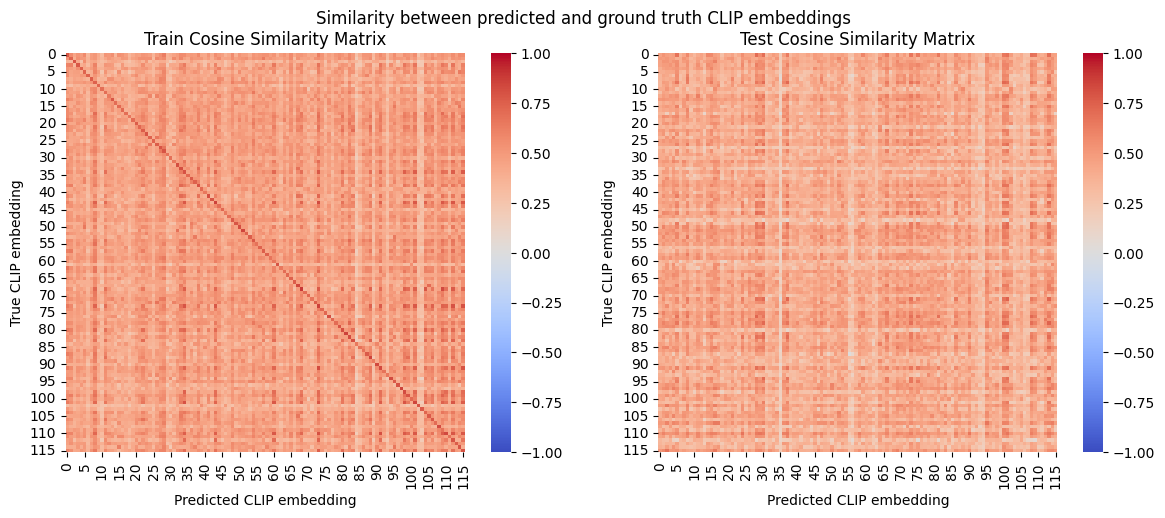

In [97]:
print('displaying every 20 train images and every 5 test images')

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(train_sims[::20, ::20], vmin=-1, vmax=1, cmap="coolwarm", square=True, ax=axs[0])
axs[0].set_title("Train Cosine Similarity Matrix")
axs[0].set_xlabel("Predicted CLIP embedding")
axs[0].set_ylabel("True CLIP embedding")

sns.heatmap(test_sims[::5, ::5], vmin=-1, vmax=1, cmap="coolwarm", square=True, ax=axs[1])
axs[1].set_title("Test Cosine Similarity Matrix")
axs[1].set_xlabel("Predicted CLIP embedding")
axs[1].set_ylabel("True CLIP embedding")

plt.suptitle('Similarity between predicted and ground truth CLIP embeddings')
plt.tight_layout()
plt.show()

In [ ]:
# Sanity checks for X,y order, NaNs, norms, dims
# Assume:
#  - binned_data shape is (n_channels, n_images, n_time_bins)
#  - image_names is list/array of length n_images (order corresponding to axis=1)
#  - clip_embeddings is array shape (n_images, emb_dim) computed separately

# Example transforms to X (images x features)
X = binned_data.transpose(1, 0, 2).reshape(binned_data.shape[1], -1)  # (n_images, n_channels*n_time_bins)
print("X shape:", X.shape)
print("X dtype:", X.dtype)
print("Any NaNs in X:", np.isnan(X).any())
print("Min/Max var of X features:", X.var(axis=0).min(), X.var(axis=0).max())

# Y (targets)
y = clip_image  # (n_images, emb_dim)
print("y shape:", y.shape)
print("Any NaNs in y:", np.isnan(y).any())
print("y mean L2 norm:", np.mean(np.linalg.norm(y, axis=1)))

# Basic alignment check: make sure your image order used for CLIP matches EEG order
print("First 10 EEG image names:", unique_image_names[:10])
print("First 10 CLIP image names:", unique_image_names[:10])  # whatever list you used when extracting CLIP embeddings
assert len(unique_image_names) == y.shape[0], "Image count mismatch"
if not np.array_equal(unique_image_names, unique_image_names):
    print("WARNING: image ordering/identity mismatch between EEG and CLIP targets")
else:
    print("Image ordering matches.")

# Check correlation structure between X and y (coarse)
sample_corr = np.corrcoef(X[:, :10].ravel(), y[:, :10].ravel())[0,1]
print("Correlation between small subset of X and y flattened:", sample_corr)